# Librairies 📚

In [45]:
# =========================
# Standard library
# =========================
import os
import sys
import time
import math
import re
import importlib

# =========================
# Data / scientific stack
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# =========================
# Stats
# =========================
import scipy.stats as stats
from scipy.stats import kruskal
import pingouin as pg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from dython.nominal import (
    associations,
    correlation_ratio,  # eta²
    cramers_v,          # V de Cramér
    theils_u            # Alternative asymétrique
)

# =========================
# Machine Learning
# =========================
import lightgbm as lgb

from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MultiLabelBinarizer,
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.svm import SVR

# =========================
# Local imports (src/)
# =========================
sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers_function as of
import src.association_report_function as ar
import src.analyse_bivariee as ab
import src.modeles_comparator as mdl
import src.tunning_parameter as tp
import src.outliers_treatment as ot

importlib.reload(of)

# =========================
# Pandas display options
# =========================
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

# Import de la table 🪑

In [148]:
building_consumption = pd.read_csv("/home/maxime/projects/building-energy-Seattle/data/external/2016_Building_Energy_Benchmarking.csv")

In [149]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",NaN,61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,196718,759392,Hotel,Hotel,"756,493.00",NaN,NaN,NaN,NaN,NaN,43.00,96.00,97.70,241.90,244.10,"72,587,024.00","73,937,112.00","21,566,554.00","14,515,435.00","49,526,664.00","14,938.00","1,493,800.00",False,NaN,Compliant,NaN,"2,089.28",2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.00",0659000640,7,DOWNTOWN,47.61,-122.34,1926,1.00,10,61320,0,61320,Hotel,Hotel,"61,320.00",NaN,NaN,NaN,NaN,NaN,56.00,110.80,113.30,216.20,224.00,"6,794,584.00","6,946,800.50","2,214,446.25","811,525.31","2,768,924.00","18,112.13","1,811,213.00",False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.00",0659000970,7,DOWNTOWN,47.61,-122.34,1980,1.00,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,"123,445.00",Parking,"68,009.00",Swimming Pool,0.00,NaN,75.00,114.80,118.70,211.40,215.60,"14,172,606.00","14,656,503.00",0.00,"1,573,448.62","5,368,607.00","88,039.98","8,803,998.00",False,NaN,Compliant,NaN,505.01,2.88


In [150]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [49]:
df = building_consumption.copy()

# Etape 1 - Premier nettoyage des données

In [50]:
df.shape

(3376, 46)

## Valeurs nulles

In [51]:
df.isna().mean().sort_values(ascending=False).head(15)

Comments                          1.00
Outlier                           0.99
YearsENERGYSTARCertified          0.96
ThirdLargestPropertyUseType       0.82
ThirdLargestPropertyUseTypeGFA    0.82
SecondLargestPropertyUseType      0.50
SecondLargestPropertyUseTypeGFA   0.50
ENERGYSTARScore                   0.25
LargestPropertyUseTypeGFA         0.01
LargestPropertyUseType            0.01
ZipCode                           0.00
ListOfAllPropertyUseTypes         0.00
Electricity(kWh)                  0.00
SourceEUIWN(kBtu/sf)              0.00
GHGEmissionsIntensity             0.00
dtype: float64

<Axes: >

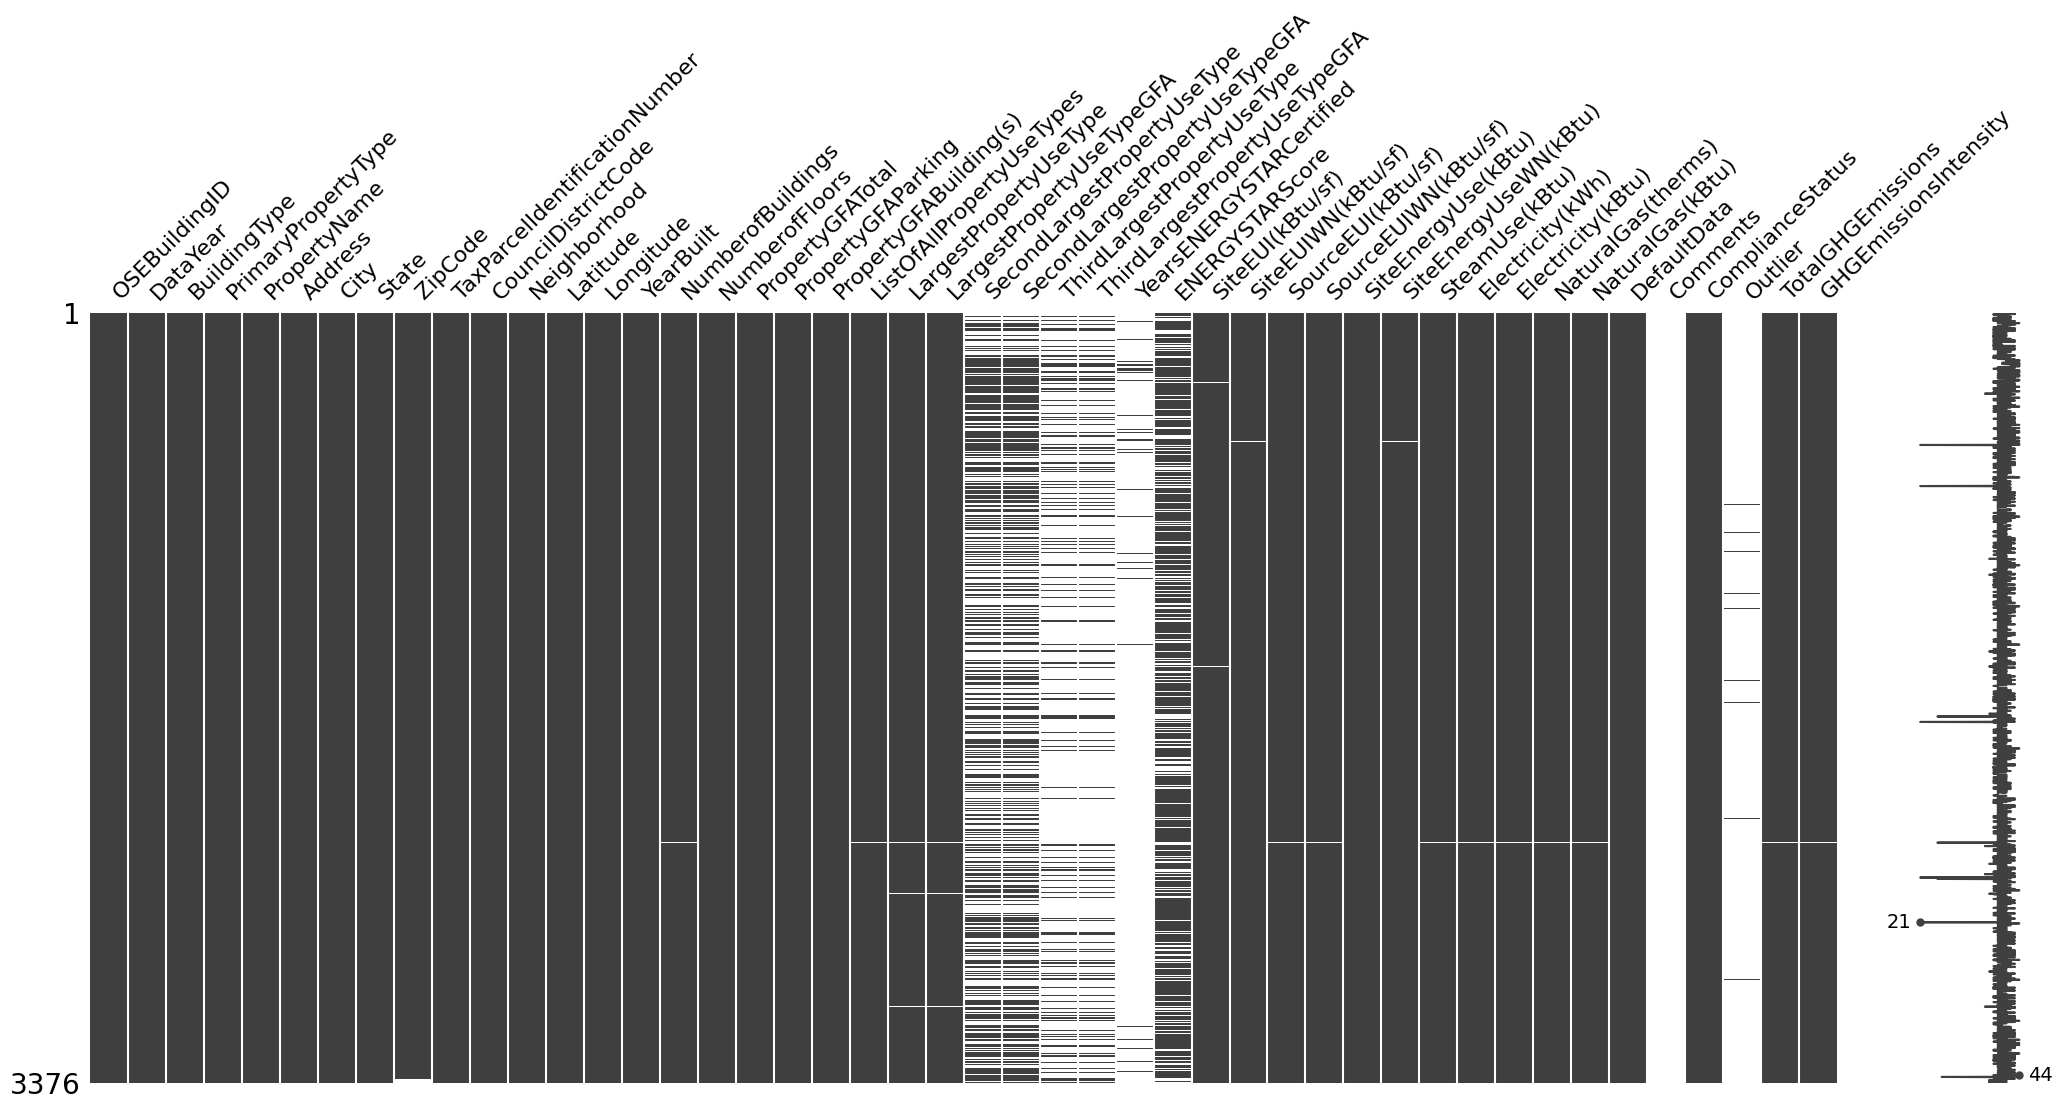

In [52]:
msno.matrix(df)

<Axes: >

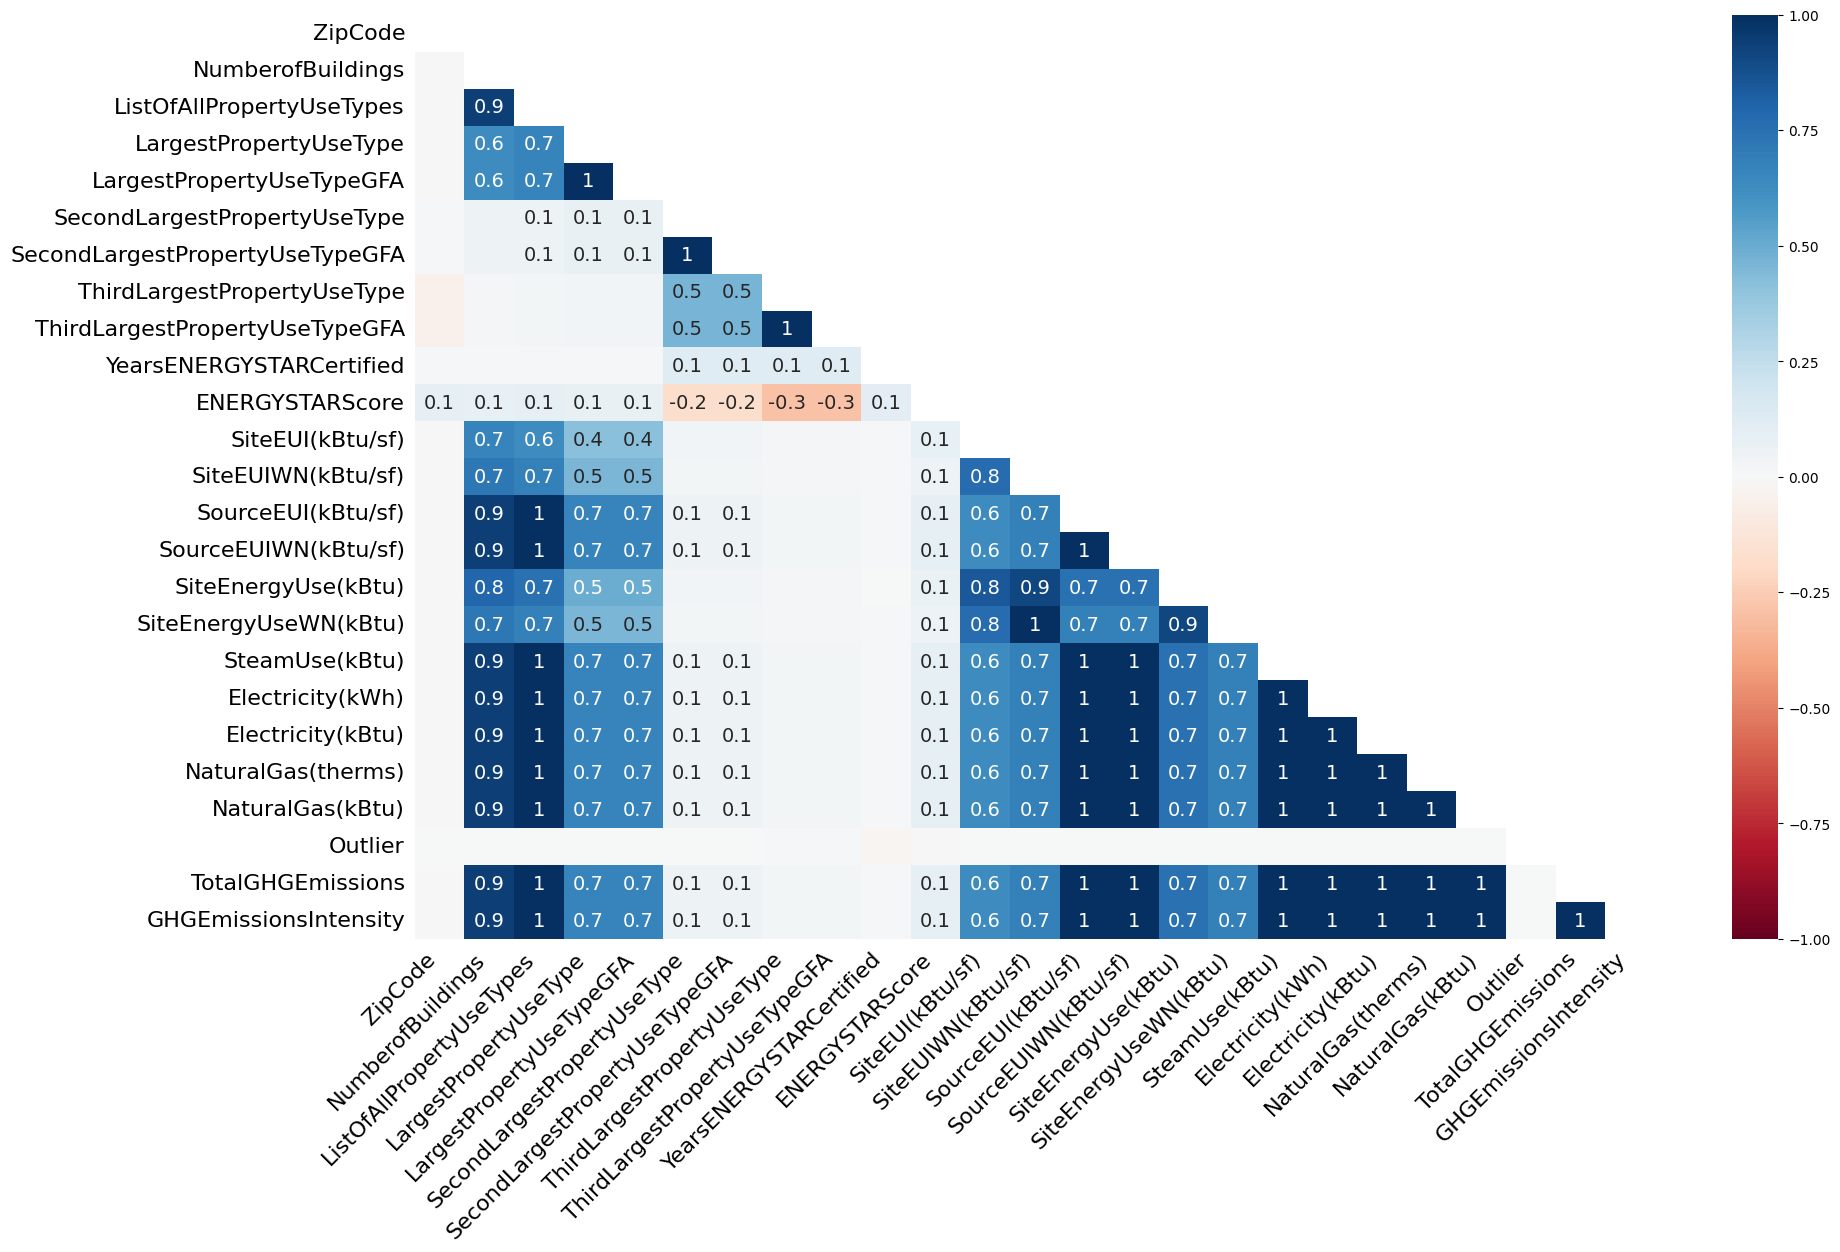

In [53]:
msno.heatmap(df)

<Axes: >

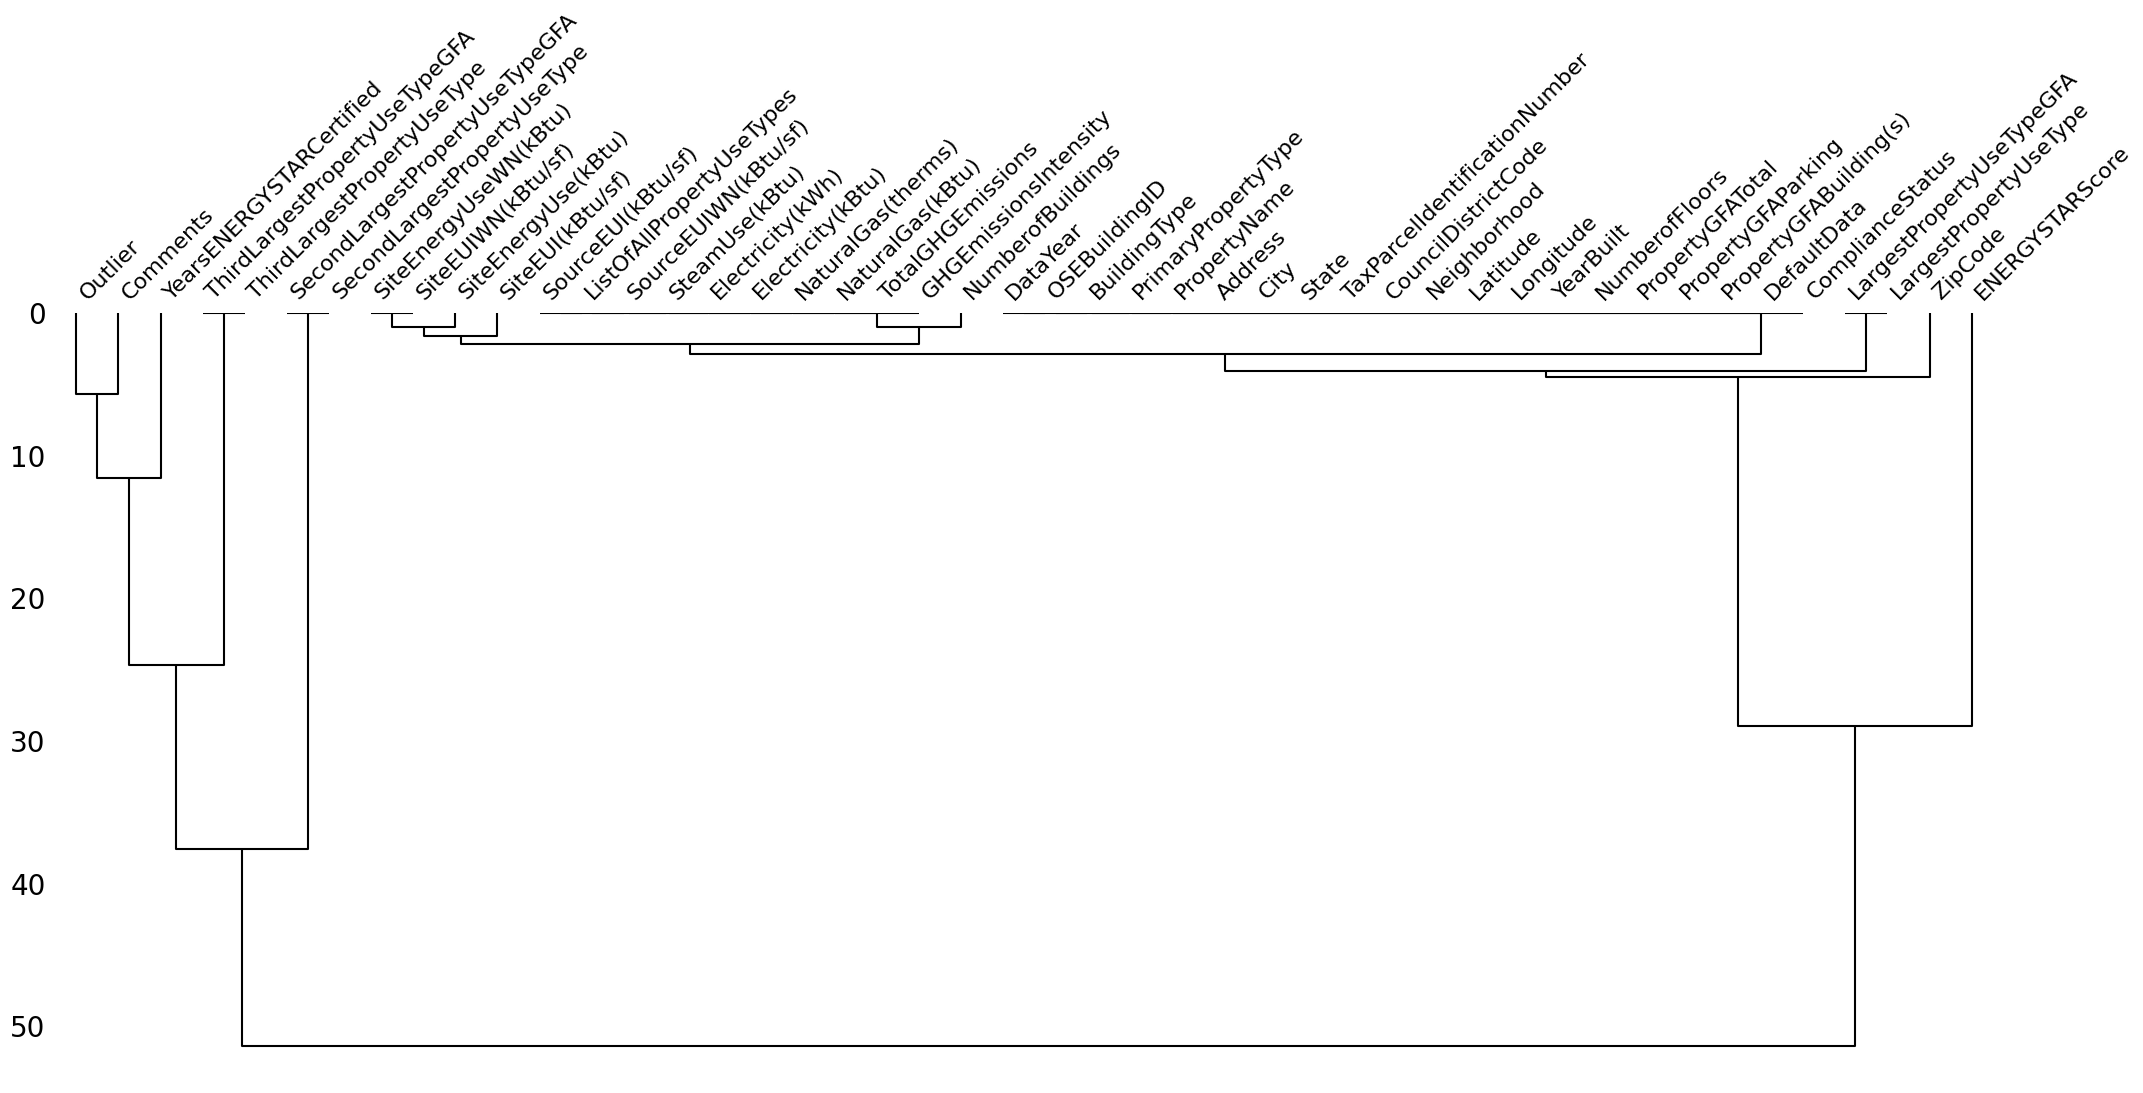

In [54]:
msno.dendrogram(df)

### Colonne Comments ❌

In [55]:
df.drop(columns="Comments",inplace=True)

### Colonne Outliers ❌

In [56]:
df[df["Outlier"].notna()]["Outlier"].value_counts()

Outlier
Low outlier     23
High outlier     9
Name: count, dtype: int64

In [57]:
df = df[~df["Outlier"].isnull() == False]
df.drop('Outlier', axis=1, inplace=True)

In [58]:
df.shape,  building_consumption.shape

((3344, 44), (3376, 46))

### Colonne YearsENERGYSTARCertified ❌ (création année's + nb_certification) ✅

In [59]:
df[df["YearsENERGYSTARCertified"].notna()].sample()
# la colonne très intéressante, il faut :
# - Séparer les années tous les 4 caractères 
# - Créer les dummies par année

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
3304,50016,2016,Multifamily MR (5-9),Mid-Rise Multifamily,AMLI Mark24,2428 NW Market St,Seattle,WA,"98,107.00",2767701150,6,BALLARD,47.67,-122.39,2014,1.00,7,418285,0,418285,"Multifamily Housing, Parking",Multifamily Housing,"418,277.00",Parking,"127,633.00",NaN,NaN,20172016,100.00,20.00,20.00,50.50,50.50,"8,374,301.00","8,374,301.00",0.00,"1,729,705.75","5,901,756.00","24,725.44","2,472,544.00",False,Compliant,172.46,0.41


In [60]:
def split_years(x):
    if pd.isna(x):
        return []
    x = str(x)
    return [x[i:i+4] for i in range(0, len(x), 4)]

df["Years_list"] = df["YearsENERGYSTARCertified"].apply(split_years)

In [61]:
df[df["YearsENERGYSTARCertified"].notna()][["YearsENERGYSTARCertified", "Years_list"]]

,YearsENERGYSTARCertified,Years_list
37,2016,[2016]
44,2016,[2016]
53,2014,[2014]
116,2016,[2016]
137,2016,[2016]
...,...,...
3281,20172016,"[2017, 2016]"
3293,2017,[2017]
3304,20172016,"[2017, 2016]"
3317,2017,[2017]


In [62]:
# Créer les dummies (One-hot encoding multi-label)
#mlb = MultiLabelBinarizer()

#years_dummies = pd.DataFrame(
#    mlb.fit_transform(df["Years_list"]), # type: ignore
#    columns=mlb.classes_,
#    index=df.index
#) # type: ignore
#years_dummies = years_dummies.astype(int)

In [63]:
#df = pd.concat([df, years_dummies], axis=1)

In [64]:
df["nb_certifications"] = df["Years_list"].apply(len)
df.drop(columns=["Years_list","YearsENERGYSTARCertified"],inplace=True)

### Colonne "Second" et "Third" ✅

In [65]:
df["nb_property_uses"] = (
    df["LargestPropertyUseType"].notna().astype(int) +
    df["SecondLargestPropertyUseType"].notna().astype(int) +
    df["ThirdLargestPropertyUseType"].notna().astype(int)
)

In [66]:
df["nb_property_uses"].value_counts()

nb_property_uses
1    1661
2    1074
3     589
0      20
Name: count, dtype: int64

In [67]:
df["NumberofBuildings"].value_counts()

NumberofBuildings
1.00      3145
0.00        92
2.00        36
3.00        22
4.00        12
5.00         9
6.00         5
8.00         3
14.00        2
9.00         2
10.00        2
27.00        1
11.00        1
7.00         1
16.00        1
23.00        1
111.00       1
Name: count, dtype: int64

/tmp/ipykernel_81671/223598007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')


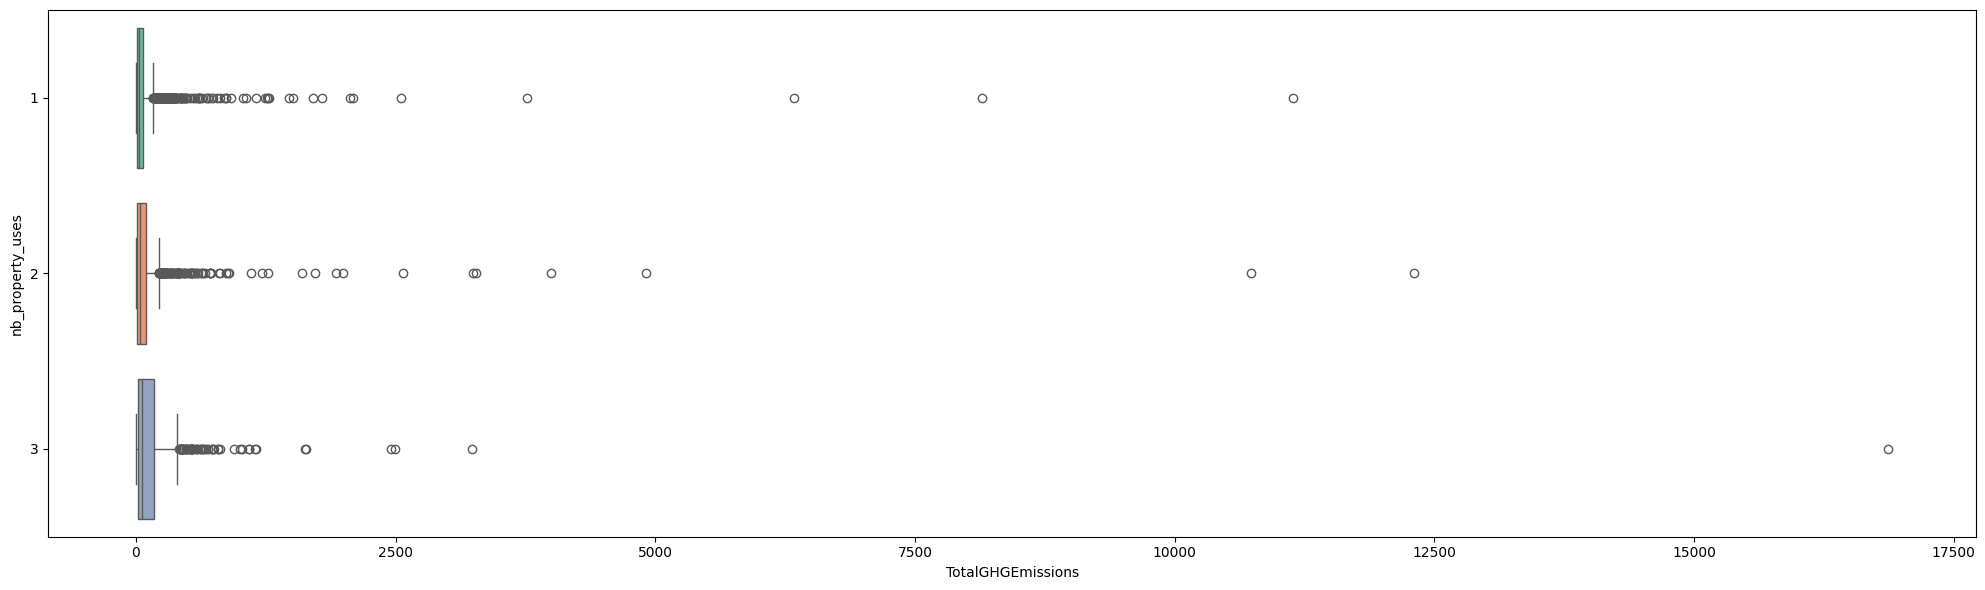

In [68]:
plt.figure(figsize=(20, 6))
data = df[df["nb_property_uses"] > 0]
sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')
plt.tight_layout()
plt.show()

In [69]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].mean()

nb_property_uses
0    65.84
1    94.57
2   125.27
3   183.72
Name: TotalGHGEmissions, dtype: float64

In [70]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].median()

nb_property_uses
0   18.95
1   26.56
2   34.18
3   61.93
Name: TotalGHGEmissions, dtype: float64

### Colonne ListOfAllPropertyUseTypes ✅ (création de nb_property_uses et is_mixed_use)

In [71]:
df["nb_property_uses"] = (
    df["ListOfAllPropertyUseTypes"]
    .fillna("")  # évite les erreurs sur NaN
    .apply(lambda x: len([u.strip() for u in x.split(",") if u.strip() != ""]))
)

In [72]:
df[["ListOfAllPropertyUseTypes", "nb_property_uses"]].head(10)

,ListOfAllPropertyUseTypes,nb_property_uses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3
5,Police Station,1
6,Hotel,1
7,Other - Entertainment/Public Assembly,1
8,Hotel,1
9,Multifamily Housing,1


In [73]:
df["is_mixed_use"] = (df["nb_property_uses"] > 1).astype(int)

## Supprimer les doublons 👥 

In [74]:
df.duplicated().sum()

np.int64(0)

## Suppression des lignes avec "DefaultData" = True et ComplianceStatus = "Compliant"

In [75]:
df["DefaultData"].value_counts(normalize=True)

DefaultData
False   0.97
True    0.03
Name: proportion, dtype: float64

In [76]:
df["ComplianceStatus"].value_counts(normalize=True)

ComplianceStatus
Compliant                      0.96
Error - Correct Default Data   0.03
Missing Data                   0.00
Non-Compliant                  0.00
Name: proportion, dtype: float64

In [77]:
df = df[df["DefaultData"] == False].copy()
df = df[df["ComplianceStatus"] == "Compliant"].copy()
df.drop(columns=["DefaultData","ComplianceStatus"])
df.shape, building_consumption.shape

((3211, 46), (3376, 46))

## Suppression des lignes avce des building hors "bâtiments non destinés à l’habitation"

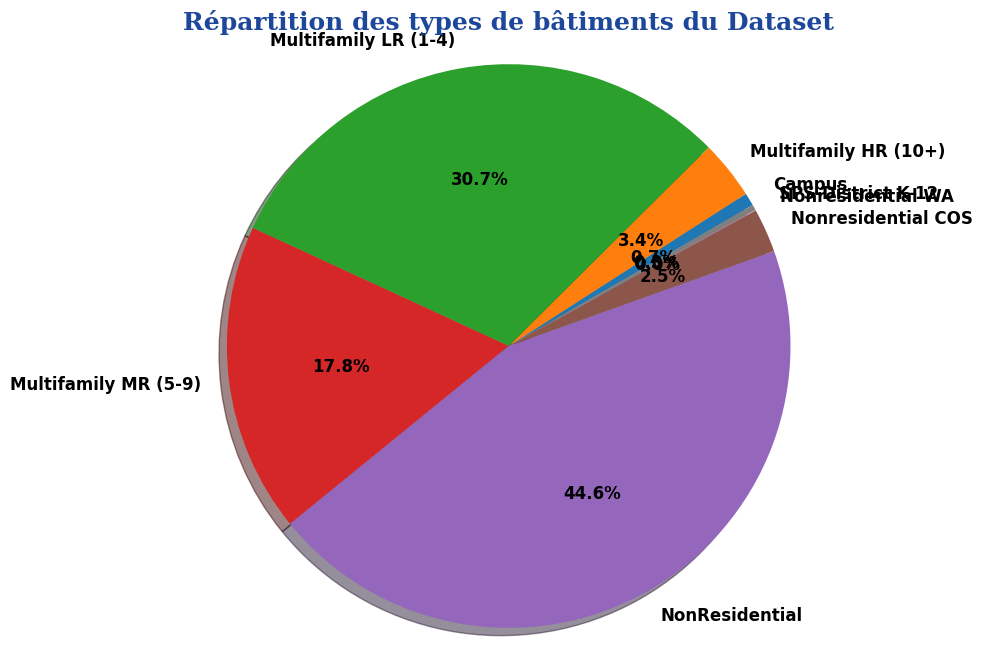

In [78]:
building_type = df.groupby(by='BuildingType')['OSEBuildingID'].nunique()

font_title = {'family': 'serif',
              'color':  '#1d479b',
              'weight': 'bold',
              'size': 18,
             }

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(building_type.values, labels=building_type.index, 
       autopct='%1.1f%%', shadow=True, startangle=30,
       textprops=dict(color="black",size=12, weight="bold"))
ax.axis('equal')
ax.set_title("Répartition des types de bâtiments du Dataset", fontdict=font_title)
plt.show()

In [79]:
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

On constate qu'il y a certains doublons dans la colonne PrimaryPropertyType.

In [80]:
regex = re.compile(r'[\n\r\t]')
df['PrimaryPropertyType'] = (
    df['PrimaryPropertyType']
        .str.replace(r'[\n\r\t]', '', regex=True)
)
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

In [81]:
val = [
    'NonResidential',
    'Nonresidential COS',
   "Campus",
    "Nonresidential WA",
    "'SPS-District K-12'"
]

df = df[df["BuildingType"].isin(val)]

## Suppression des colonnes avec toujours la même valeurs

In [82]:
df = df.loc[:, df.nunique() > 1]

In [83]:
df.shape, building_consumption.shape

((1538, 41), (3376, 46))

## Suppression des variables redondantes

In [84]:
redundant_features = ['NaturalGas(therms)','Electricity(kWh)']
df.drop(redundant_features, axis=1, inplace=True)

In [85]:
df[df["NumberofBuildings"] != df["nb_property_uses"]][["NumberofBuildings","nb_property_uses"]].shape

(888, 2)

## Suppresion des colonnes WN

Les suffixes WN : "Weather Normalized" - Ce sont les mesures normalisées avec les conditions climatiques. Dans le cadre de notre analyse, la météo ne rentrera pas en compte.

In [86]:
def search_componant(df, suffix=None):
  componant = []
  for col in df.columns:
      if suffix in col: 
        componant.append(col)
  return componant

In [87]:
df.drop(search_componant(df,'WN'), axis=1, inplace=True)

## Ajout d'une colonne bulding age

In [88]:
df["building_age"] = 2016 - df["YearBuilt"]

## Autres traitements

In [89]:
df["CouncilDistrictCode"] = df["CouncilDistrictCode"].astype("category")
df["ZipCode"] = df["ZipCode"].astype("category")

In [90]:
df["Neighborhood"] = df["Neighborhood"].str.upper().str.strip()

# Etape 2 - Analyse Exploratoire

## Analyse univariée

In [91]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,"1,538.00","16,527.60","13,835.26",1.00,604.25,"21,182.50","24,619.00","50,226.00"
Latitude,"1,538.00",47.62,0.05,47.51,47.59,47.61,47.65,47.73
Longitude,"1,538.00",-122.33,0.02,-122.41,-122.34,-122.33,-122.32,-122.26
YearBuilt,"1,538.00","1,961.54",32.87,"1,900.00","1,930.00","1,965.00","1,988.00","2,015.00"
NumberofBuildings,"1,538.00",1.18,3.05,0.00,1.00,1.00,1.00,111.00
NumberofFloors,"1,538.00",4.29,6.80,0.00,1.00,2.00,4.00,99.00
PropertyGFATotal,"1,538.00","121,122.57","307,114.22","11,285.00","28,811.00","48,013.00","106,030.75","9,320,156.00"
PropertyGFAParking,"1,538.00","13,932.34","43,849.52",0.00,0.00,0.00,0.00,"512,608.00"
PropertyGFABuilding(s),"1,538.00","107,190.23","293,382.35","3,636.00","27,884.00","45,985.50","94,853.25","9,320,156.00"
LargestPropertyUseTypeGFA,"1,534.00","99,697.61","286,278.49","5,656.00","25,000.00","41,705.50","91,862.50","9,320,156.00"


### Colonnes numérique

In [92]:
data = df.select_dtypes(include="number").copy()

In [93]:
data.sample(1)

,OSEBuildingID,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,nb_certifications,nb_property_uses,is_mixed_use,building_age
2835,27145,47.60,-122.33,2000,1.00,6,706176,0,706176,"222,807.00","78,049.00","5,171.00",82.00,58.20,182.80,"13,270,687.00",0.00,"13,270,685.00",0.00,92.52,0.13,2,3,1,16


In [95]:
cols_to_drop = [
    "OSEBuildingID",
    "Latitude","Longitude","YearBuilt", 'is_mixed_use'#,'nb_certifications',"nb_property_uses","NumberofBuildings","NumberofFloors"
]

data = data.drop(cols_to_drop,axis=1)

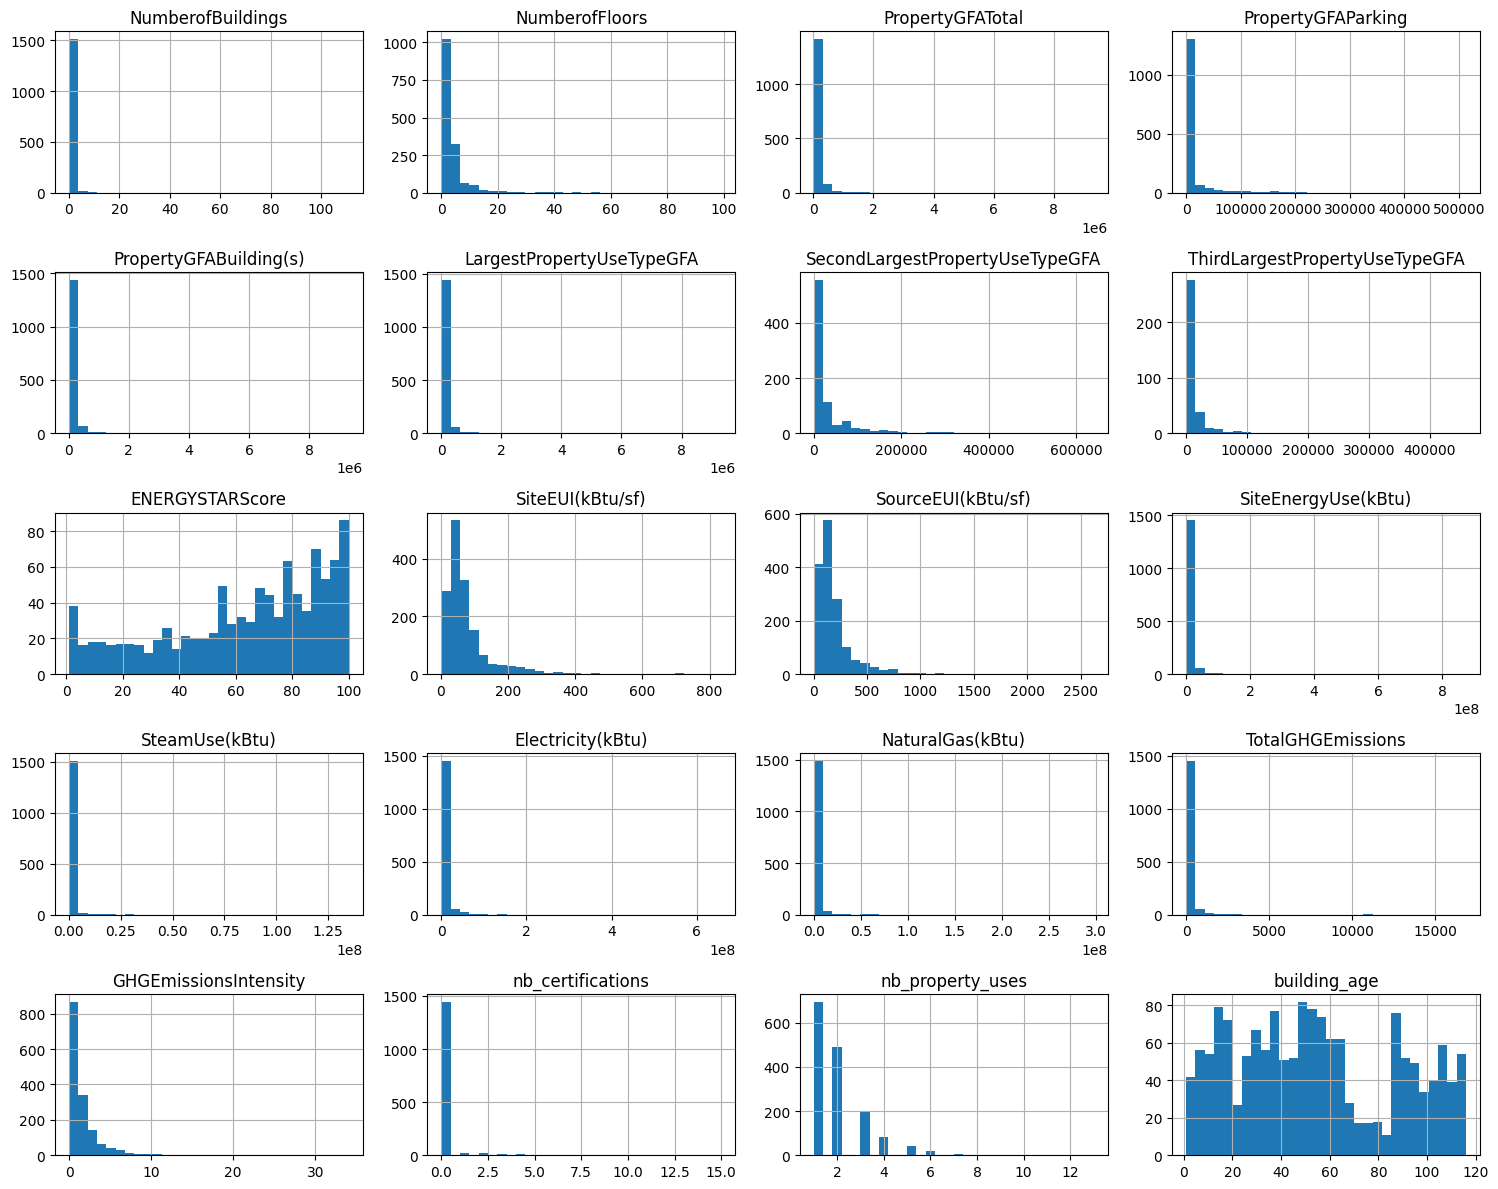

In [96]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

In [97]:
data.skew().sort_values(ascending=False) # asymértie des données sur la droite (sauf ENERGYSTARScore) ==> normaliser les données pour avoir une meilleure distribution

NumberofBuildings                 31.26
LargestPropertyUseTypeGFA         22.74
NaturalGas(kBtu)                  21.30
PropertyGFABuilding(s)            21.28
Electricity(kBtu)                 20.18
PropertyGFATotal                  18.79
SteamUse(kBtu)                    18.39
SiteEnergyUse(kBtu)               17.42
TotalGHGEmissions                 13.68
ThirdLargestPropertyUseTypeGFA     7.57
nb_certifications                  7.03
NumberofFloors                     5.82
PropertyGFAParking                 5.01
SourceEUI(kBtu/sf)                 4.94
GHGEmissionsIntensity              4.55
SecondLargestPropertyUseTypeGFA    3.76
SiteEUI(kBtu/sf)                   3.68
nb_property_uses                   2.19
building_age                       0.28
ENERGYSTARScore                   -0.66
dtype: float64

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


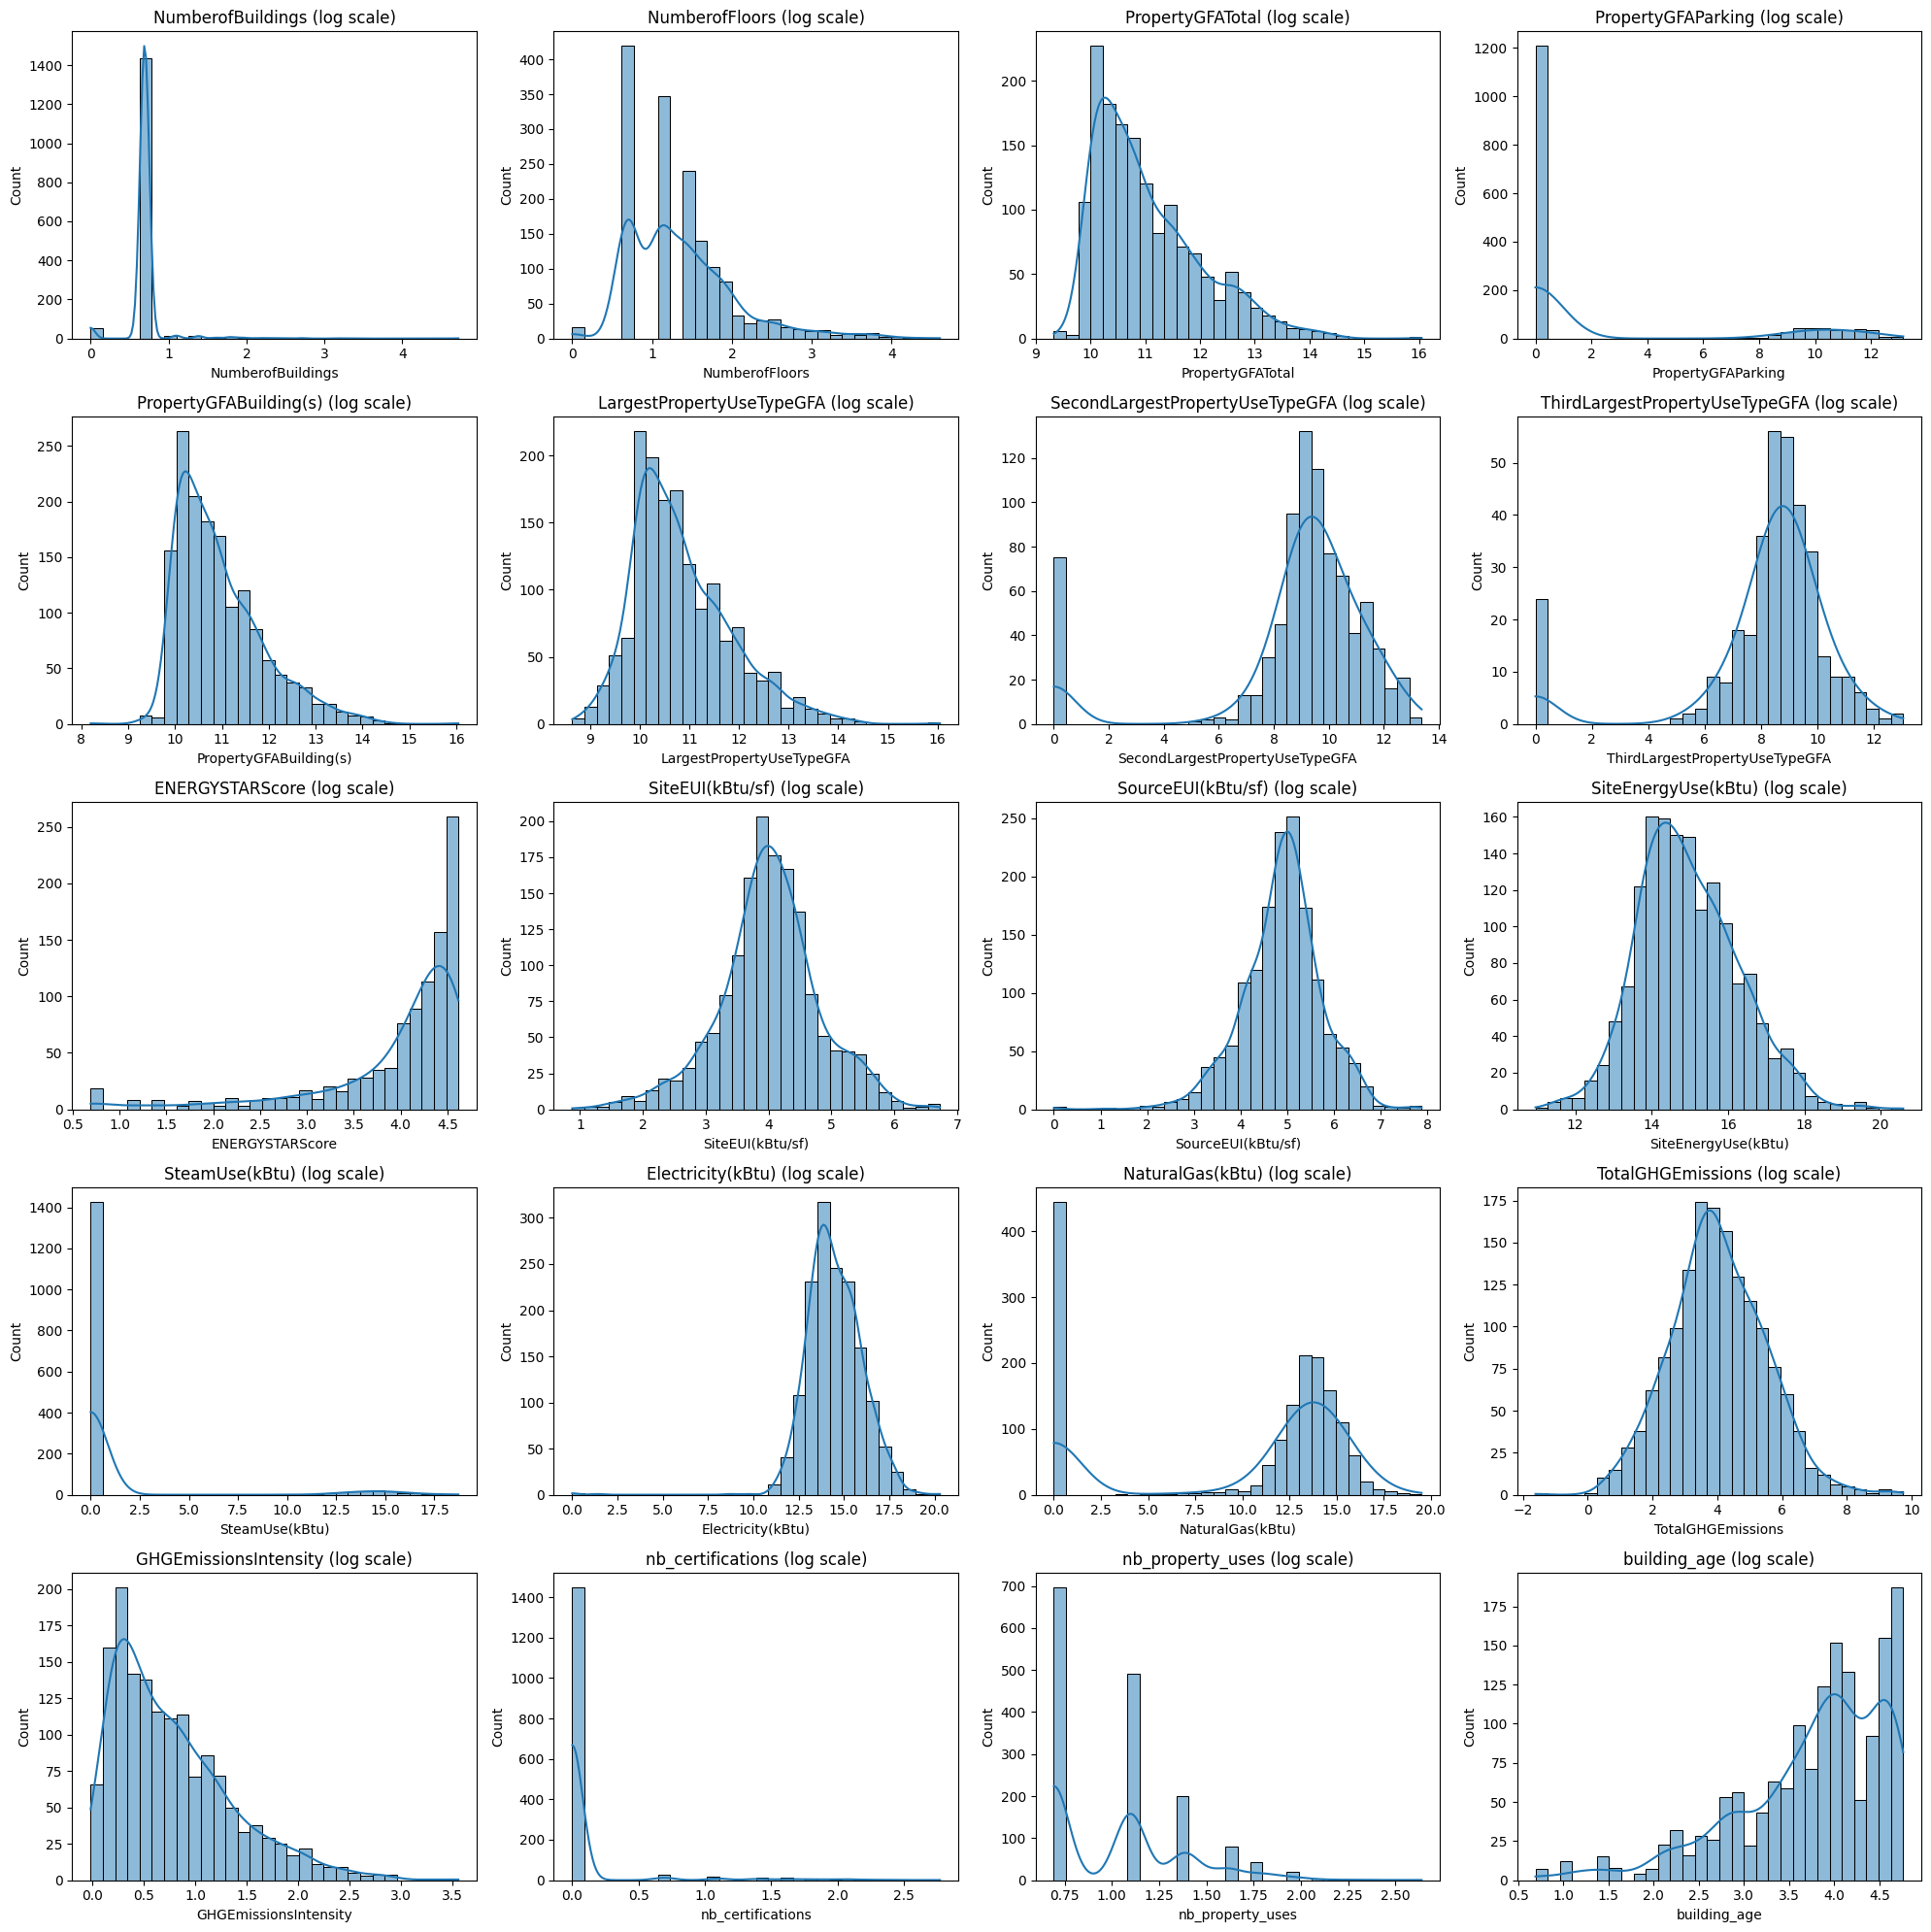

In [98]:
cols = data.columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cols):
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log scale)")

# Supprimer les axes vides si nombre impair
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


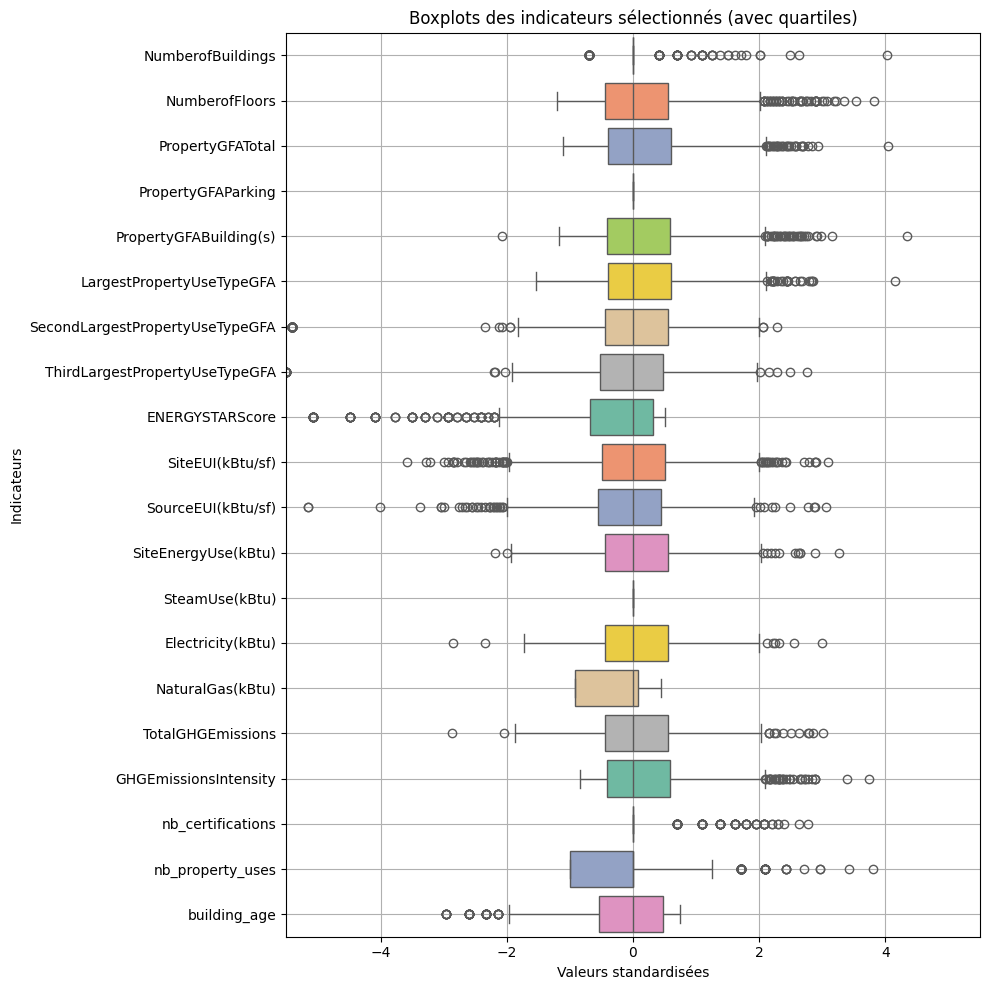

In [99]:
data_log = np.log1p(data)

data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data_log),
    columns=data.columns
)

plt.figure(figsize=(10, 10))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("Indicateurs")
plt.xlabel("Valeurs standardisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()


Les consommations et émissions sont fortement concentrées sur un petit nombre de bâtiments.

In [100]:
outliers, ratio = of.detect_outliers_iqr(data)

ratio.sort_values(ascending=False)

PropertyGFAParking                21.46
PropertyGFATotal                  12.48
SiteEnergyUse(kBtu)               11.38
Electricity(kBtu)                 11.25
NaturalGas(kBtu)                  11.12
PropertyGFABuilding(s)            10.99
TotalGHGEmissions                 10.92
LargestPropertyUseTypeGFA         10.34
nb_property_uses                   9.82
SiteEUI(kBtu/sf)                   9.43
NumberofFloors                     8.97
GHGEmissionsIntensity              8.71
SecondLargestPropertyUseTypeGFA    7.93
SourceEUI(kBtu/sf)                 7.93
SteamUse(kBtu)                     7.35
NumberofBuildings                  6.76
nb_certifications                  5.92
ThirdLargestPropertyUseTypeGFA     2.34
ENERGYSTARScore                    0.00
building_age                       0.00
dtype: float64

### Colonnes catégorielles 

In [107]:
cat_cols = df.select_dtypes(exclude="number").columns

In [147]:
df.select_dtypes(exclude="number").columns

Index(['BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address',
       'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode',
       'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'age_bin'],
      dtype='str')

In [109]:
# Nombre de modalités
for col in cat_cols:
    print(col, ":", df[col].nunique())

BuildingType : 4
PrimaryPropertyType : 21
PropertyName : 1534
Address : 1517
ZipCode : 48
TaxParcelIdentificationNumber : 1458
CouncilDistrictCode : 7
Neighborhood : 14
ListOfAllPropertyUseTypes : 369
LargestPropertyUseType : 55
SecondLargestPropertyUseType : 47
ThirdLargestPropertyUseType : 39


In [110]:
# Distribution brute
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 BuildingType
BuildingType
NonResidential        1432
Nonresidential COS      81
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

 PrimaryPropertyType
PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          243
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     42
Name: count, dtype: int64

 PropertyName
PropertyName
South Park                     2
Canal Building                 2
Bayview Building               2
Airport Way                    2
Mayflower park hotel           1
Paramount Hotel                1
5673-The Westin Seattle        1
HOTEL MAX                      1
WARWICK SEATTLE HOTEL (ID8)    1
West Precinct                  1
Name: count, dtype: int64

 Address
Address
2600 SW Barton St 

In [112]:
df.select_dtypes(exclude="number").info()

<class 'pandas.DataFrame'>
Index: 1538 entries, 0 to 3375
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   BuildingType                   1538 non-null   str     
 1   PrimaryPropertyType            1538 non-null   str     
 2   PropertyName                   1538 non-null   str     
 3   Address                        1538 non-null   str     
 4   ZipCode                        1525 non-null   category
 5   TaxParcelIdentificationNumber  1538 non-null   str     
 6   CouncilDistrictCode            1538 non-null   category
 7   Neighborhood                   1538 non-null   str     
 8   ListOfAllPropertyUseTypes      1538 non-null   str     
 9   LargestPropertyUseType         1534 non-null   str     
 10  SecondLargestPropertyUseType   840 non-null    str     
 11  ThirdLargestPropertyUseType    347 non-null    str     
dtypes: category(2), str(10)
memory usage: 340.9 KB


In [123]:
df["ZipCode"].value_counts().nlargest(20).reset_index()

,ZipCode,count
0,"98,134.00",180
1,"98,104.00",153
2,"98,101.00",144
3,"98,109.00",137
4,"98,108.00",111
5,"98,122.00",86
6,"98,121.00",83
7,"98,105.00",80
8,"98,103.00",63
9,"98,119.00",60


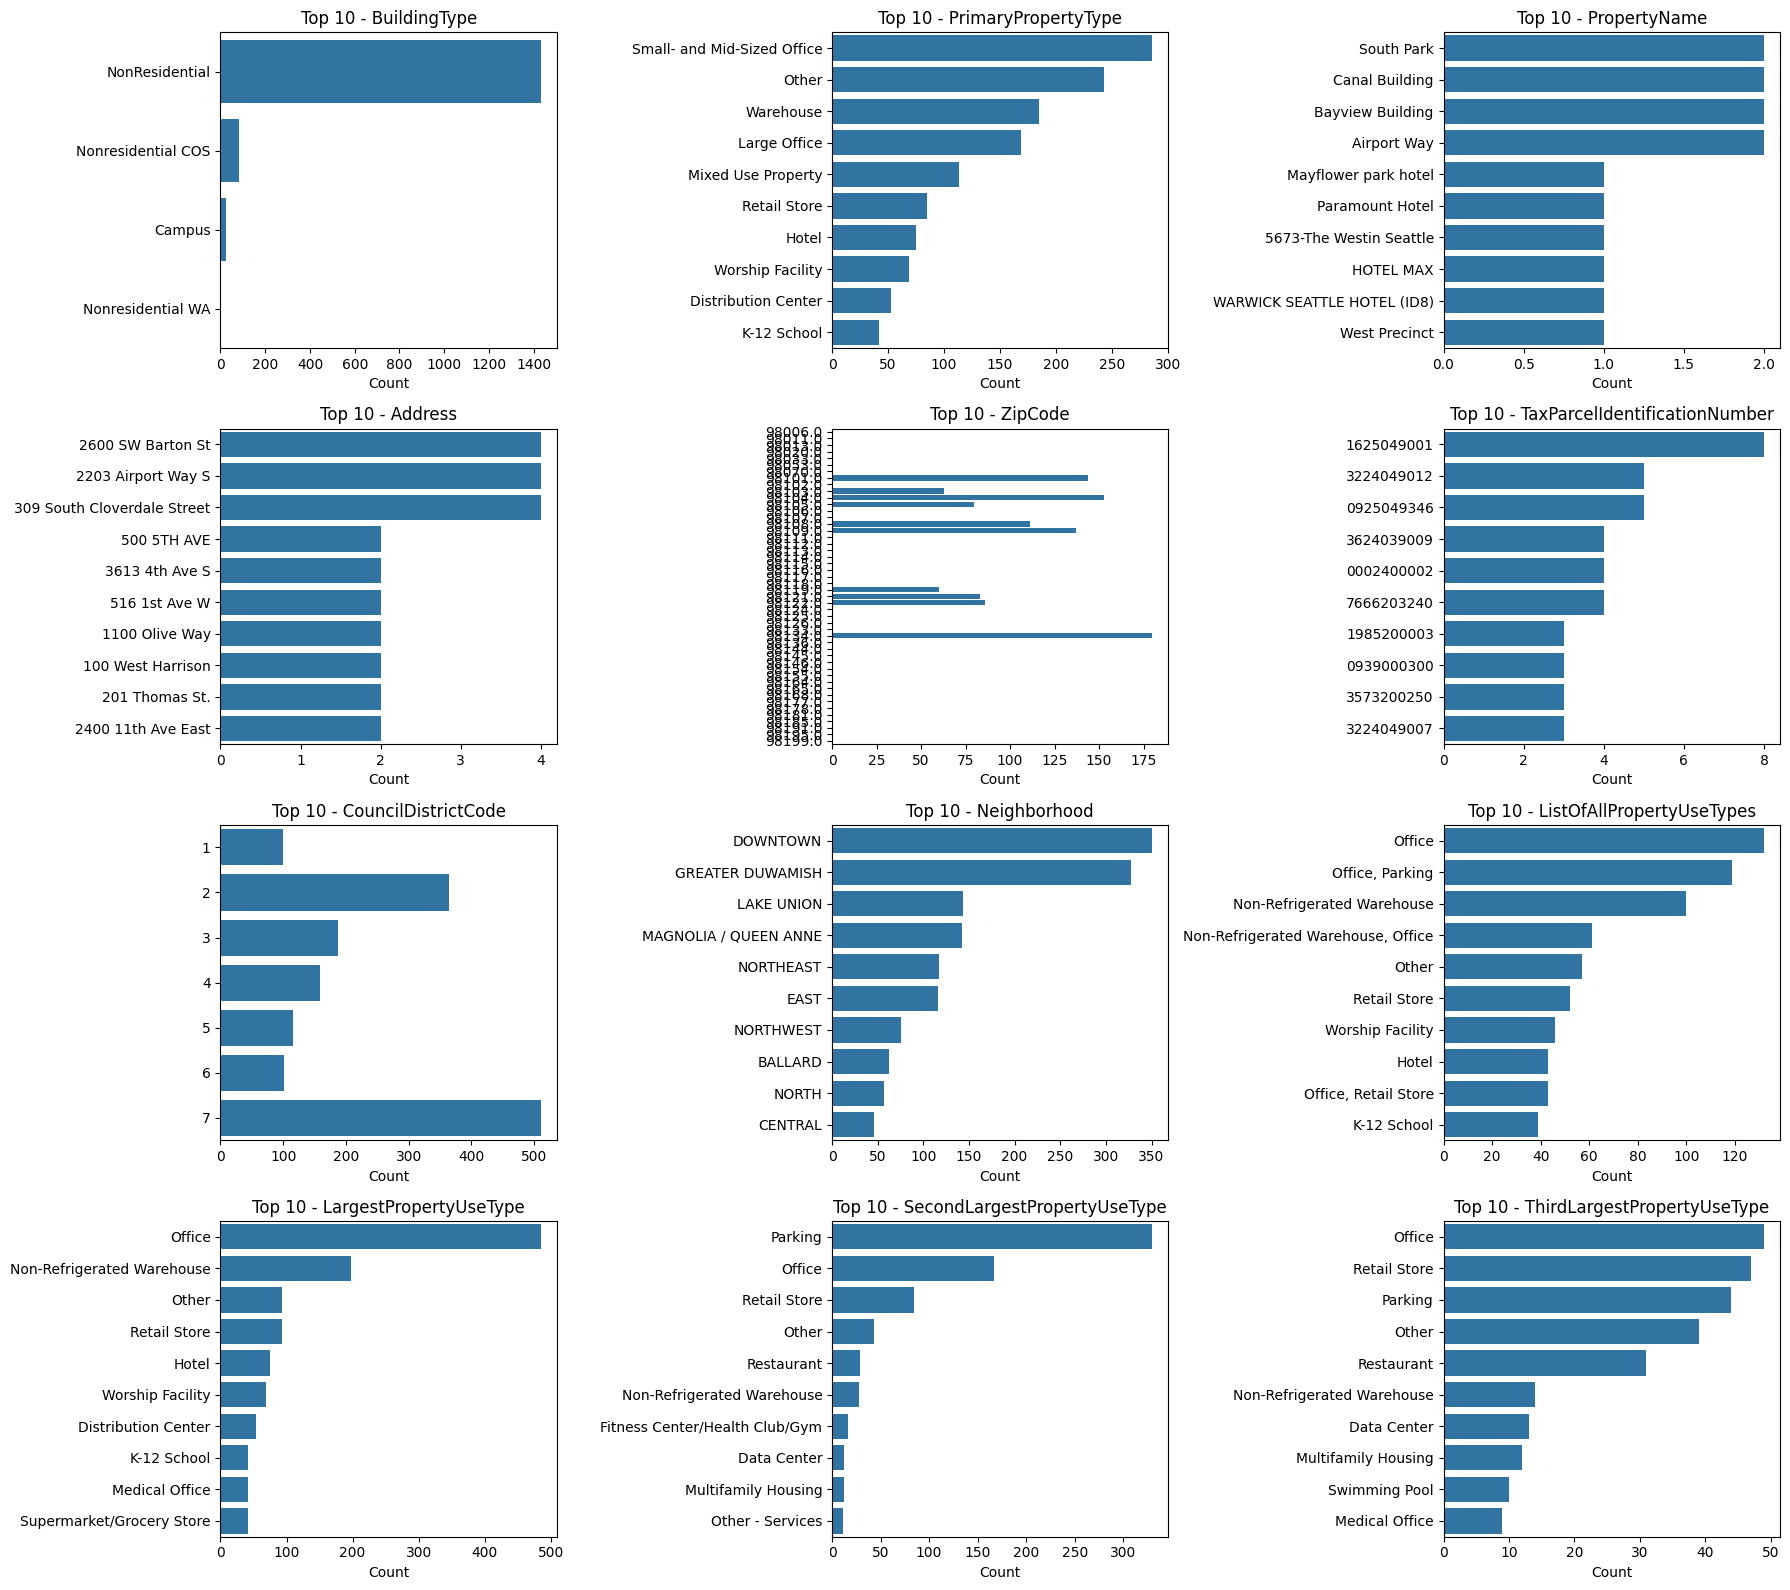

In [125]:
n_cols = 3
n_plots = len(cat_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cat_cols):
    
    ax = axes[i]
    
    top_categories = df[col].value_counts().nlargest(10)
    
    sns.barplot(
        x=top_categories.values,
        y=top_categories.index,
        ax=ax
    )
    
    ax.set_title(f"Top 10 - {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

# Supprimer les axes vides si cat_cols < n_rows * n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Analyse bivariée

In [126]:
col_sel = [
        'CouncilDistrictCode',
        'YearBuilt',
        'NumberofBuildings',
        'NumberofFloors',
        'PropertyGFATotal',
        'SiteEnergyUse(kBtu)',
        'SiteEUI(kBtu/sf)',
        'SourceEUI(kBtu/sf)',
        'TotalGHGEmissions',
        'GHGEmissionsIntensity',
        'ENERGYSTARScore',
        'SteamUse(kBtu)',
        'Electricity(kBtu)',
        'nb_certifications',
        'nb_property_uses',
        'is_mixed_use'
 ]

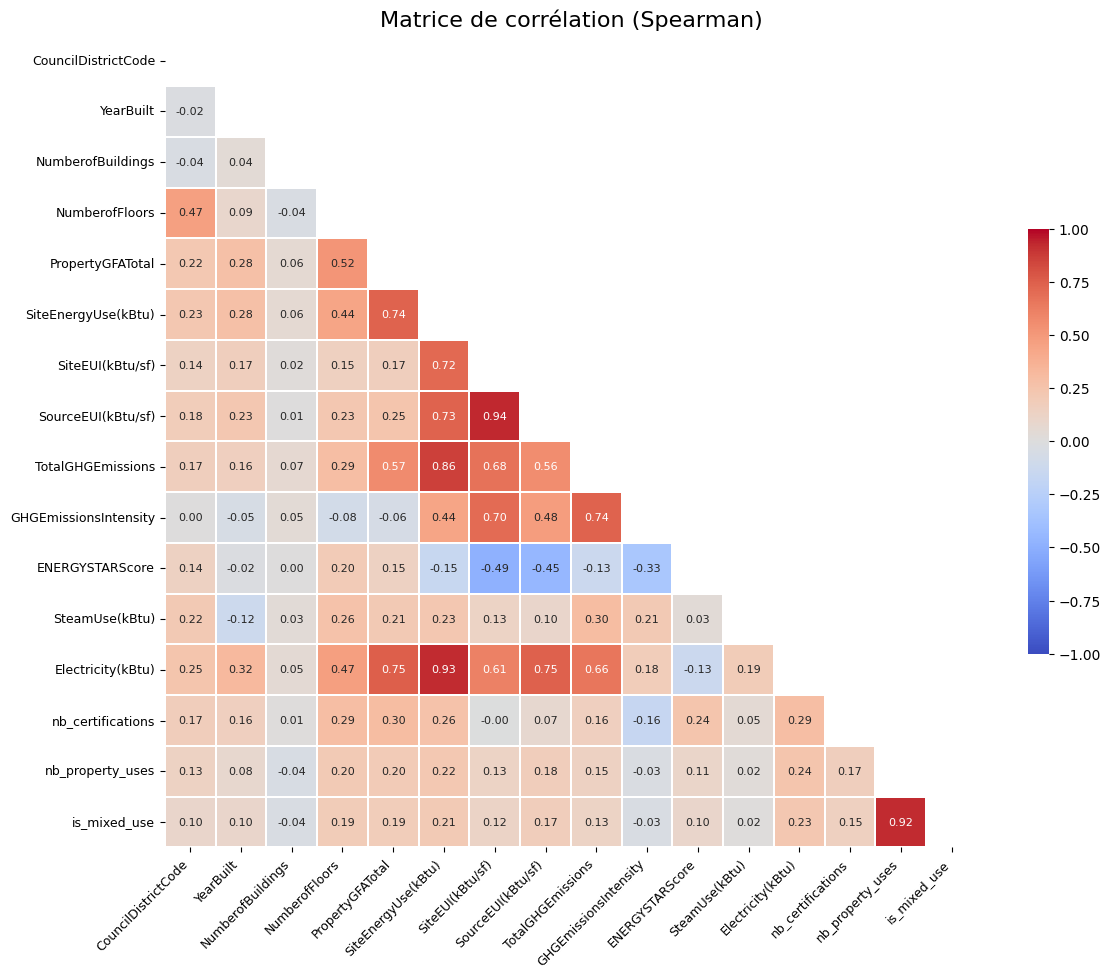

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = df[col_sel]
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

### Problème de colinéarité

In [128]:
corr = df.select_dtypes(include="number").corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,PropertyGFATotal,PropertyGFABuilding(s),0.98
1,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.94
2,SiteEnergyUse(kBtu),Electricity(kBtu),0.93
3,nb_property_uses,is_mixed_use,0.92
4,PropertyGFATotal,LargestPropertyUseTypeGFA,0.92
5,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,0.92
6,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
7,NaturalGas(kBtu),GHGEmissionsIntensity,0.76
8,PropertyGFATotal,Electricity(kBtu),0.75
9,SourceEUI(kBtu/sf),Electricity(kBtu),0.75


On remarque que les variables suffixées GFA présentent de fortes corrélations avec plusieurs autres variables. 

Nous allons à présent convertir les différentes surfaces (Buildings et Parking) en pourcentage de la surface totale et nous conserverons uniquement ces 2 variables en supprimant les variables LargestPropertyUseTypeGFA, SecondLargestPropertyUseTypeGFA, ThirdLargestPropertyUseTypeGFA :

In [129]:
# --- Ratios GFA ---
df['buildings_gfa_ratio'] = ot.safe_divide(
    df['PropertyGFABuilding(s)'],
    df['PropertyGFATotal']
)

df['parking_gfa_ratio'] = ot.safe_divide(
    df['PropertyGFAParking'],
    df['PropertyGFATotal']
)

df["largest_use_ratio"] = ot.safe_divide(
    df["LargestPropertyUseTypeGFA"],
    df["PropertyGFATotal"]
)

# --- Ratios structurels ---
df['gfa_per_building'] = ot.safe_divide(
    df['PropertyGFATotal'],
    df['NumberofBuildings']
)

df["gfa_per_floor"] = ot.safe_divide(
    df["PropertyGFATotal"],
    df["NumberofFloors"]
)

In [130]:
#df["is_monofunctional"] = (df["largest_use_ratio"] > 0.8).astype(int)
#On supprime les variables inutiles
df.drop(['LargestPropertyUseTypeGFA', 
           'SecondLargestPropertyUseTypeGFA',
           'SecondLargestPropertyUseType',
           'ThirdLargestPropertyUseTypeGFA',
           'ThirdLargestPropertyUseType',
           'PropertyGFAParking',
           'PropertyGFABuilding(s)'],
         axis=1, inplace=True)

#On complète les usages de la partie la plus large
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].fillna("Unknown")
df['NumberofFloors'] = df['NumberofFloors'].fillna(1)

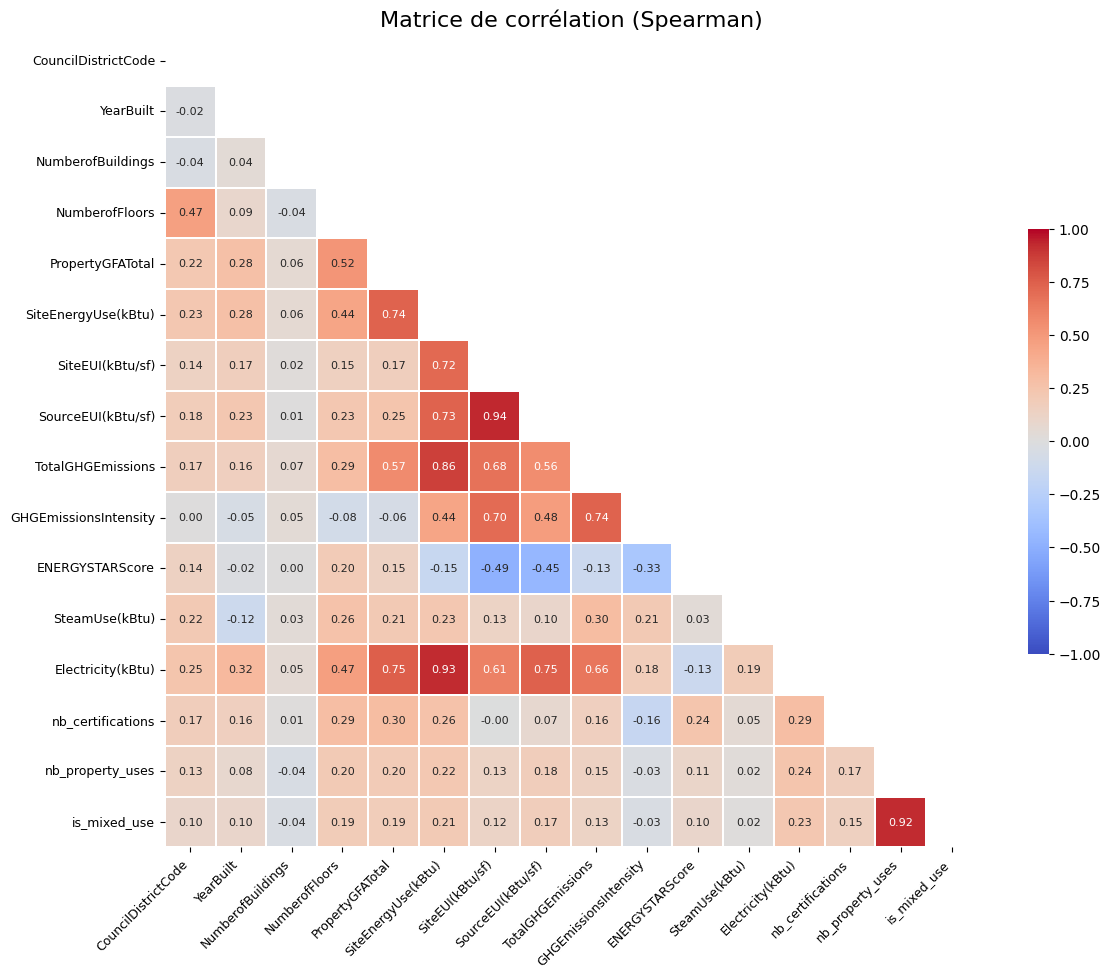

In [131]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = df[col_sel]
corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},          # réduire taille des valeurs réduite
    linewidths=0.3,
    linecolor="white",
    square=True,                    # cellules carrées
    vmin=-1, vmax=1,                # échelle fixe (important pour comparaison)
    cbar_kws={"shrink": 0.5}
)

plt.title("Matrice de corrélation (Spearman)", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

In [132]:
corr = df.select_dtypes(include="number").corr(method="spearman")

mask = np.triu(np.ones_like(corr, dtype=bool)) # matrice de 1 de la même taille que corr + garde uniquement la partie triangulaire supérieure
corr_tri = corr.mask(mask) # suppression de la diagonale et de la partie supérieur de la matrice

strong_corr = (pd.DataFrame(
    corr_tri.unstack()
    .dropna()
    .loc[lambda x: abs(x) > 0.7]
    .sort_values(ascending=False)
    .reset_index()
    )
)
strong_corr.columns = ["level_0", "level_1", "corr"]
strong_corr

,level_0,level_1,corr
0,PropertyGFATotal,gfa_per_building,0.96
1,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.94
2,SiteEnergyUse(kBtu),Electricity(kBtu),0.93
3,nb_property_uses,is_mixed_use,0.92
4,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
5,NaturalGas(kBtu),GHGEmissionsIntensity,0.76
6,PropertyGFATotal,Electricity(kBtu),0.75
7,SourceEUI(kBtu/sf),Electricity(kBtu),0.75
8,TotalGHGEmissions,GHGEmissionsIntensity,0.74
9,PropertyGFATotal,SiteEnergyUse(kBtu),0.74


In [133]:
strong_corr_features = list(set(list(strong_corr['level_0'].values) + list(strong_corr['level_1'].values)))
X = df[strong_corr_features].replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(len(X.columns))]
vif_data[vif_data['VIF'] > 5]

/home/maxime/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,Electricity(kBtu),429.81
1,building_age,inf
2,SourceEUI(kBtu/sf),26.63
3,TotalGHGEmissions,87.13
4,SiteEUI(kBtu/sf),36.46
5,SiteEnergyUse(kBtu),987.43
6,NaturalGas(kBtu),14.74
7,YearBuilt,inf
9,parking_gfa_ratio,inf
10,gfa_per_building,8.30


Des scores VIF supérieur à 5 indiquent généralement une forte multicolinéarité. Ces variables fortement corrélées risquent de biaiser nos modèles.
Les features suffixées EUI(kBtu/sf), sont des variables dont les valeurs sont ramenées à la surface par étage. Nous allons les supprimer car nous avons créer des variables pouvant permettre de ramener nos données à l'étage ou au building. Idem pour la variable GHGEmissionsIntensity

In [134]:
eui_features = search_componant(df, suffix='EUI(kBtu/sf)') + ['GHGEmissionsIntensity']
df.drop(eui_features, axis=1, inplace=True)

# Etape 2 - feature engineering

## Ajout d'une colonne age bin

In [135]:
df["age_bin"] = pd.cut(
    df["building_age"],
    bins=[0,20,40,60,80,150],
    labels=["0-20","20-40","40-60","60-80","80+"]
)

## Ajout d'une colonne surface log

In [136]:
df["log_gfa"] = np.log1p(df["PropertyGFATotal"])

## Ajout colonnes sources et proportion d’énergie 

Très clairement, si j'ajoute la consommation d'énergie, ces variables risques de biaiser le modèle. Mais je peux faire des colonnes bool qui indique si un bâtiment utilise telle ou telle énergie.

In [137]:
df["has_gas"] = (df["NaturalGas(kBtu)"] > 0).astype(int)
df["has_electricity"] = (df["Electricity(kBtu)"] > 0).astype(int)
df["has_steam"] = (df["SteamUse(kBtu)"] > 0).astype(int) 

# Création des trois nouvelles variables avec les proportions d'utilisation de gaz/électricité/vapeur
df['gas_prop'] = df['NaturalGas(kBtu)'] / df['SiteEnergyUse(kBtu)']
df['elec_prop'] = df['Electricity(kBtu)'] / df['SiteEnergyUse(kBtu)']
df['steam_prop'] = df['SteamUse(kBtu)'] / df['SiteEnergyUse(kBtu)']

#df.drop(["NaturalGas(kBtu)","Electricity(kBtu)","SteamUse(kBtu)","PropertyName", "Address", "TaxParcelIdentificationNumber"],axis=1,inplace=True)

## Suppression des valeurs aberrantes

In [138]:
df = df[df['SiteEnergyUse(kBtu)'] < 2e8]
df = df.loc[df['NumberofFloors'] < 90]
df.loc[df['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1
df = df[df['TotalGHGEmissions'] > 0]


In [139]:
num_df = df.select_dtypes(include=np.number)

neg_stats = pd.DataFrame({
    "nb_negatives": (num_df < 0).sum(),
    "pct_negatives": (num_df < 0).mean() * 100,
    "min_value": num_df.min(),
    "mean": num_df.mean()
})

neg_stats = neg_stats[neg_stats["nb_negatives"] > 0] \
            .sort_values("nb_negatives", ascending=False)

neg_stats

,nb_negatives,pct_negatives,min_value,mean
Longitude,1529,100.00,-122.41,-122.33


## Traitement des valeurs extrêmes

In [140]:
outliers, ratio = of.detect_outliers_iqr(df.select_dtypes(include="number"))

ratio.sort_values(ascending=False)

parking_gfa_ratio     21.58
buildings_gfa_ratio   21.58
Longitude             12.49
PropertyGFATotal      12.23
gfa_per_building      11.51
Electricity(kBtu)     11.12
SiteEnergyUse(kBtu)   11.12
NaturalGas(kBtu)      11.05
TotalGHGEmissions     10.66
nb_property_uses       9.74
NumberofFloors         8.76
SteamUse(kBtu)         7.19
has_steam              7.19
steam_prop             7.19
gfa_per_floor          6.80
nb_certifications      5.95
NumberofBuildings      3.14
log_gfa                1.90
largest_use_ratio      1.50
has_electricity        0.07
YearBuilt              0.00
ENERGYSTARScore        0.00
OSEBuildingID          0.00
Latitude               0.00
building_age           0.00
is_mixed_use           0.00
has_gas                0.00
gas_prop               0.00
elec_prop              0.00
dtype: float64

D'abord, on va sécuriser les ratio. 

Ensuite, on voit que les colonnes PropertyGFATotal, SiteEnergyUse(kBtu), Electricity(kBtu), NaturalGas(kBtu), TotalGHGEmissions ont beaucoup de valeurs aberrantes. On a déjà traité et écarté Electricity(kBtu) et NaturalGas(kBtu). Concentrons nous sur les 3 autres.

In [141]:
ratio_cols = [
    "buildings_gfa_ratio",
    "parking_gfa_ratio",
    "largest_use_ratio",
    "gfa_per_building",
    "gfa_per_floor"
]

df[ratio_cols].describe()

,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,gfa_per_building,gfa_per_floor
count,"1,529.00","1,529.00","1,525.00","1,477.00","1,514.00"
mean,0.93,0.07,0.86,"108,015.99","32,725.10"
std,0.14,0.14,0.31,"187,689.48","48,030.15"
min,0.10,0.00,0.19,"4,300.00","3,230.77"
25%,1.00,0.00,0.67,"28,080.00","12,937.00"
50%,1.00,0.00,0.94,"45,864.00","22,076.50"
75%,1.00,0.00,1.00,"99,586.50","35,972.91"
max,1.00,0.90,6.43,"2,200,000.00","1,100,000.00"


In [142]:
ratio_defs = {
    "buildings_gfa_ratio": ("PropertyGFABuilding(s)", "PropertyGFATotal"),
    "parking_gfa_ratio": ("PropertyGFAParking", "PropertyGFATotal"),
    "largest_use_ratio": ("LargestPropertyUseTypeGFA", "PropertyGFATotal"),
    "gfa_per_building": ("PropertyGFATotal", "NumberofBuildings"),
    "gfa_per_floor": ("PropertyGFATotal", "NumberofFloors"),
}

df_clean, report = ot.handle_outliers_turnkey(
    df,
    ratio_defs=ratio_defs,
    cap_factor=3.0,          # doux, adapté énergie
    log_skew_threshold=1.0,  # ok par défaut
    verbose=True
)

✅ Outlier handling done
- Numeric cols: 29 (binary excluded: 4)
- log1p applied on: 11 columns

Top outlier ratios BEFORE (IQR 1.5):


,outlier_pct
buildings_gfa_ratio,21.58
parking_gfa_ratio,21.58
Longitude,12.49
PropertyGFATotal,12.23
gfa_per_building,11.84
Electricity(kBtu),11.12
SiteEnergyUse(kBtu),11.12
NaturalGas(kBtu),11.05
TotalGHGEmissions,10.66
nb_property_uses,9.74



Top outlier ratios AFTER (IQR 1.5):


,outlier_pct
Longitude,12.49
nb_property_uses,9.74
NumberofFloors,8.76
gfa_per_building,2.16
PropertyGFATotal,1.90
largest_use_ratio,1.51
gfa_per_floor,1.25
log_gfa,1.11
TotalGHGEmissions,0.59
SiteEnergyUse(kBtu),0.46


In [143]:
df.head(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,ListOfAllPropertyUseTypes,LargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,nb_certifications,nb_property_uses,is_mixed_use,building_age,buildings_gfa_ratio,parking_gfa_ratio,largest_use_ratio,gfa_per_building,gfa_per_floor,age_bin,log_gfa,has_gas,has_electricity,has_steam,gas_prop,elec_prop,steam_prop
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,Hotel,Hotel,60.00,"7,226,362.50","2,003,882.00","3,946,027.00","1,276,453.00",249.98,0,1,0,89,1.00,0.00,1.00,"88,434.00","7,369.50",80+,11.39,1,1,1,0.18,0.55,0.28
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,"Hotel, Parking, Restaurant",Hotel,61.00,"8,387,933.00",0.00,"3,242,851.00","5,145,082.00",295.86,0,3,1,20,0.85,0.15,0.81,"103,566.00","9,415.09",0-20,11.55,1,1,0,0.61,0.39,0.00
2,3,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,Hotel,Hotel,43.00,"72,587,024.00","21,566,554.00","49,526,664.00","1,493,800.00","2,089.28",0,1,0,47,0.79,0.21,0.79,"956,110.00","23,319.76",40-60,13.77,1,1,1,0.02,0.68,0.30
3,5,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,"98,101.00",0659000640,7,DOWNTOWN,47.61,-122.34,1926,1.00,10,61320,Hotel,Hotel,56.00,"6,794,584.00","2,214,446.25","2,768,924.00","1,811,213.00",286.43,0,1,0,90,1.00,0.00,1.00,"61,320.00","6,132.00",80+,11.02,1,1,1,0.27,0.41,0.33
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,"98,121.00",0659000970,7,DOWNTOWN,47.61,-122.34,1980,1.00,18,175580,"Hotel, Parking, Swimming Pool",Hotel,75.00,"14,172,606.00",0.00,"5,368,607.00","8,803,998.00",505.01,0,3,1,36,0.65,0.35,0.70,"175,580.00","9,754.44",20-40,12.08,1,1,0,0.62,0.38,0.00


In [146]:
df.info()

<class 'pandas.DataFrame'>
Index: 1529 entries, 0 to 3375
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   OSEBuildingID                  1529 non-null   int64   
 1   BuildingType                   1529 non-null   str     
 2   PrimaryPropertyType            1529 non-null   str     
 3   PropertyName                   1529 non-null   str     
 4   Address                        1529 non-null   str     
 5   ZipCode                        1516 non-null   category
 6   TaxParcelIdentificationNumber  1529 non-null   str     
 7   CouncilDistrictCode            1529 non-null   category
 8   Neighborhood                   1529 non-null   str     
 9   Latitude                       1529 non-null   float64 
 10  Longitude                      1529 non-null   float64 
 11  YearBuilt                      1529 non-null   int64   
 12  NumberofBuildings              1529 non-null   flo

In [145]:
df.to_csv("/home/maxime/projects/building-energy-Seattle/data/processed/data_to_use.csv")